In [1]:
print("Hello545985848484")

Hello545985848484


https://www.youtube.com/post/UgkxEgzkcz1Jx1fsxVj2-chUjMDBmLkvBL-v


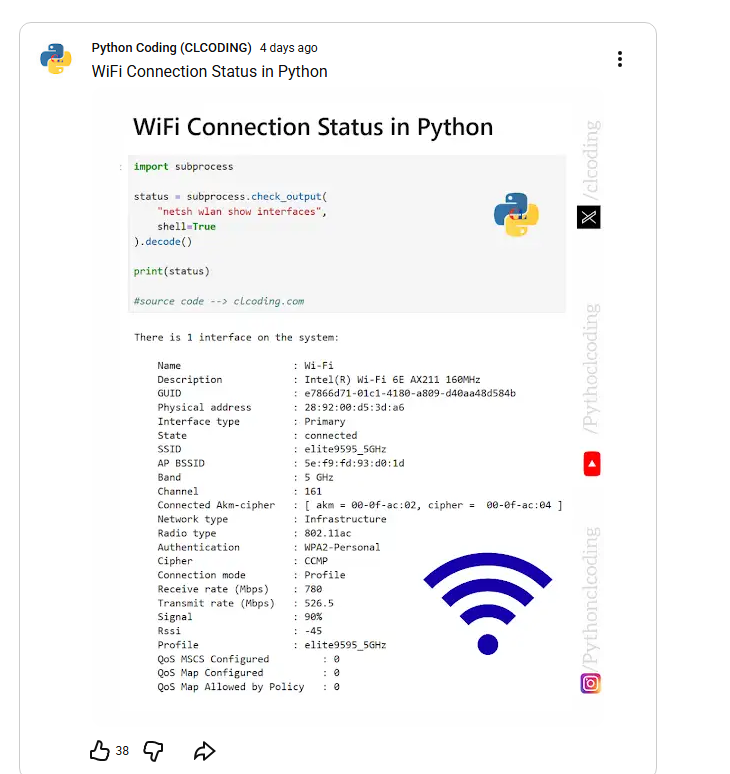

In [2]:
!pip install subprocess

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement subprocess (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for subprocess


In [3]:
import subprocess

status = subprocess.check_output("netsh wlan show interfaces", shell=True).decode()

print(status)

CalledProcessError: Command 'netsh wlan show interfaces' returned non-zero exit status 1.

In [4]:
import subprocess

try:
    status = subprocess.check_output("netsh wlan show interfaces", shell=True).decode()
    print(status)
except:
    print(f"The code returned process error")



The code returned process error


In [5]:
import subprocess

result = subprocess.run(
    "netsh wlan show interfaces",
    shell=True,
    capture_output=True,
    text=True
)

print("Return Code:", result.returncode)
print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)

Return Code: 1
STDOUT:
The Wireless AutoConfig Service (wlansvc) is not running.

STDERR:



In [6]:
import subprocess

output = subprocess.check_output(
    ["netsh", "wlan", "show", "interfaces"],
    text=True
)

print(output)

CalledProcessError: Command '['netsh', 'wlan', 'show', 'interfaces']' returned non-zero exit status 1.

In [7]:
import subprocess

try:
    output = subprocess.check_output(
        ["netsh", "wlan", "show", "interfaces"],
        text=True
    )
    print(output)

except subprocess.CalledProcessError as e:
    print("Command Failed")
    print("Return Code:", e.returncode)

except FileNotFoundError:
    print("netsh command not found")

Command Failed
Return Code: 1


The error is:

```python
CalledProcessError: Command 'netsh wlan show interfaces' returned non-zero exit status 1.
```

This means the command itself failed, not the Python code.

### First, see the actual error message

Replace your code with:

```python
import subprocess

result = subprocess.run(
    "netsh wlan show interfaces",
    shell=True,
    capture_output=True,
    text=True
)

print("Return Code:", result.returncode)
print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)
```

This will show the real reason `netsh` is failing.

***

### Common Causes

#### 1. No Wireless Adapter

Run in CMD:

```cmd
netsh wlan show interfaces
```

If you get:

```text
There is no wireless interface on the system.
```

then your machine does not have an active Wi-Fi adapter.

***

#### 2. WLAN AutoConfig Service Disabled

Check:

```cmd
services.msc
```

Find:

```text
WLAN AutoConfig
```

Make sure it is:

```text
Status: Running
Startup Type: Automatic
```

or from CMD:

```cmd
sc query wlansvc
```

***

#### 3. Running in WSL/Linux

If you are running Python in:

```text
WSL
Linux
Docker
```

`netsh` does not exist there.

Check:

```python
import platform
print(platform.system())
```

It must return:

```text
Windows
```

***

#### 4. Python from Microsoft Store

Your traceback shows:

```text
PythonSoftwareFoundation.Python.3.13
```

which is the Microsoft Store version. Sometimes subprocess execution behaves differently.

Try:

```python
import subprocess

output = subprocess.check_output(
    ["netsh", "wlan", "show", "interfaces"],
    text=True
)

print(output)
```

instead of using `shell=True`.

***

### Safer Version

```python
import subprocess

try:
    output = subprocess.check_output(
        ["netsh", "wlan", "show", "interfaces"],
        text=True
    )
    print(output)

except subprocess.CalledProcessError as e:
    print("Command Failed")
    print("Return Code:", e.returncode)

except FileNotFoundError:
    print("netsh command not found")
```

### Verify Outside Python

Before debugging Python, run this in Command Prompt:

```cmd
netsh wlan show interfaces
```

If that command fails there too, the issue is with Windows/Wi-Fi configuration, not Python.

Please paste the output of:

```cmd
netsh wlan show interfaces
```

from Command Prompt, and I can identify the exact root cause.


https://www.youtube.com/post/Ugkxjv-cMB6CdFA9mWMZJQ0UGaDNU18GHRtg



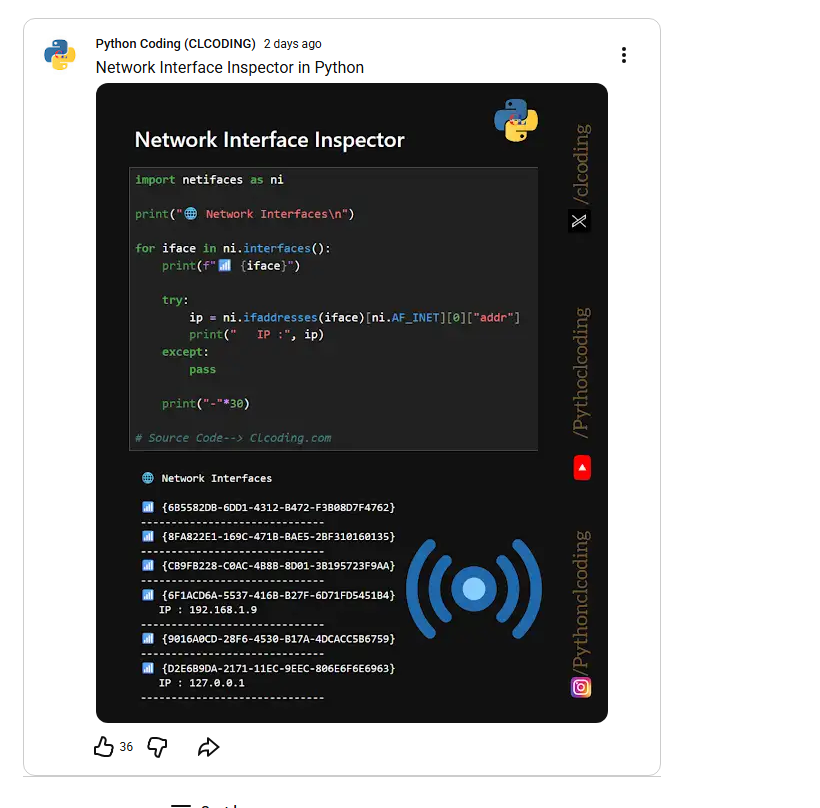


In [8]:
!pip install netifaces

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for netifaces: filename=netifaces-0.11.0-cp313-cp313-win_amd64.whl size=16344 sha256=a56f9462d2266d53b9e8614c6b4bad611c5b4afc5524d06ea7069bbdf9e2edbc
  Stored in directory: c:\users\v-yaalam\appdata\local\pip\cache\wheels\b6\30\e2\f47e3db48aecfc634b24146b62f520b4419b0bd90ef9ed1760
Successfully built netifaces



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import netifaces as ni
print("Network Interfaces\n")

for iface in ni.interfaces():
    print(f" symbol {iface}")

    try:
        ip = ni.ifaddresses(iface)[ni.AF_INET][0]["addr"]
        print("   IP:   ", ip)
    except:
        pass
    print("_"*30)

Network Interfaces

 symbol {EE5D58FE-35D0-4B0C-8825-A527F098AC4B}
   IP:    10.0.9.200
______________________________
 symbol {9ACC5697-0F79-4C2A-B9D7-F89CC314D5EC}
   IP:    192.168.229.1
______________________________
 symbol {3F298E2B-FE46-4581-BEFA-A08694E0FBE4}
   IP:    192.168.32.1
______________________________
 symbol {C5FCC1DC-06CB-11F1-93A3-806E6F6E6963}
   IP:    127.0.0.1
______________________________
 symbol {E469F6EB-35DF-4D30-815E-7CB09E606936}
   IP:    172.31.160.1
______________________________


In [10]:
import netifaces as ni

for iface in ni.interfaces():

    print(f"\nInterface: {iface}")

    addrs = ni.ifaddresses(iface)

    if ni.AF_INET in addrs:
        ipv4 = addrs[ni.AF_INET][0]

        print("IP Address :", ipv4.get("addr"))
        print("Netmask    :", ipv4.get("netmask"))
        print("Broadcast  :", ipv4.get("broadcast"))

    if ni.AF_LINK in addrs:
        print("MAC Address:", addrs[ni.AF_LINK][0].get("addr"))

    print("-" * 50)


Interface: {EE5D58FE-35D0-4B0C-8825-A527F098AC4B}
IP Address : 10.0.9.200
Netmask    : 255.255.128.0
Broadcast  : 10.0.127.255
MAC Address: 00:0d:3a:fd:68:b8
--------------------------------------------------

Interface: {9ACC5697-0F79-4C2A-B9D7-F89CC314D5EC}
IP Address : 192.168.229.1
Netmask    : 255.255.255.0
Broadcast  : 192.168.229.255
MAC Address: 00:50:56:c0:00:01
--------------------------------------------------

Interface: {3F298E2B-FE46-4581-BEFA-A08694E0FBE4}
IP Address : 192.168.32.1
Netmask    : 255.255.255.0
Broadcast  : 192.168.32.255
MAC Address: 00:50:56:c0:00:08
--------------------------------------------------

Interface: {C5FCC1DC-06CB-11F1-93A3-806E6F6E6963}
IP Address : 127.0.0.1
Netmask    : 255.0.0.0
Broadcast  : 127.255.255.255
MAC Address: 
--------------------------------------------------

Interface: {E469F6EB-35DF-4D30-815E-7CB09E606936}
IP Address : 172.31.160.1
Netmask    : 255.255.240.0
Broadcast  : 172.31.175.255
MAC Address: 00:15:5d:71:52:bc
------

https://www.youtube.com/post/UgkxEGCSB-p-BcYSL44DLjhf5kVIWyrP1rDB


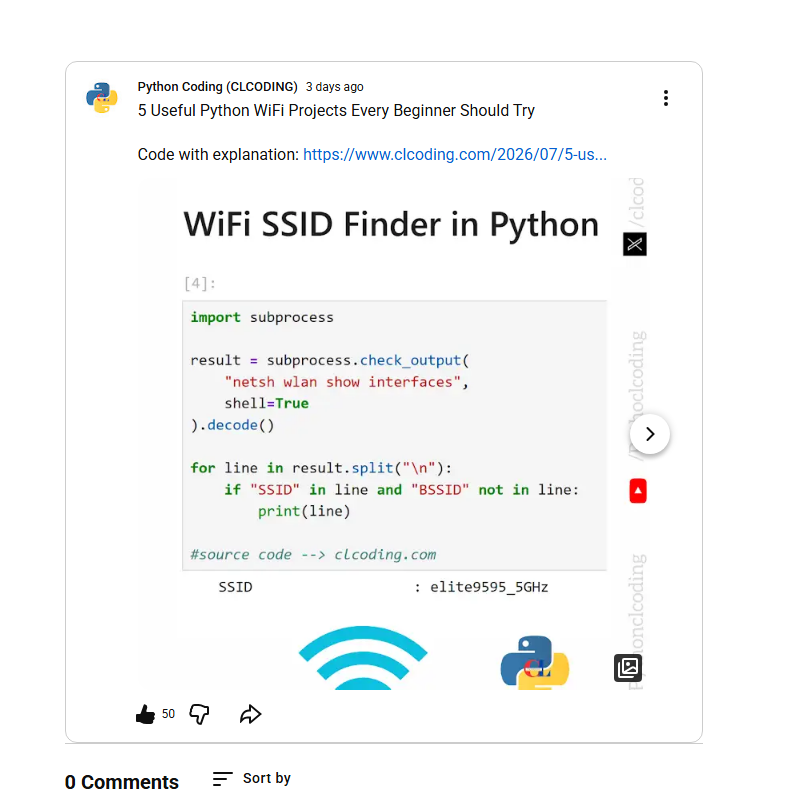

In [1]:
!pip install subprocess

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement subprocess (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for subprocess


In [2]:
import subprocess

result = subprocess.check_output("netsh wlan show interfaces",shell=True).decode()

for line in result.split("\n"):
    if "SSID" in line and  "BSSID" not in line:
        print(line)

CalledProcessError: Command 'netsh wlan show interfaces' returned non-zero exit status 1.

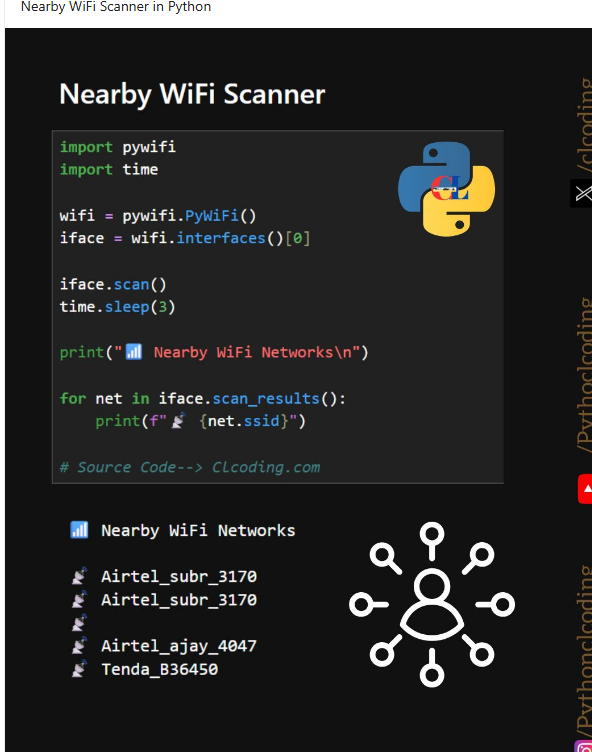


https://www.linkedin.com/posts/nearby-wifi-scanner-in-python-share-7481260630411268097-KhRA/


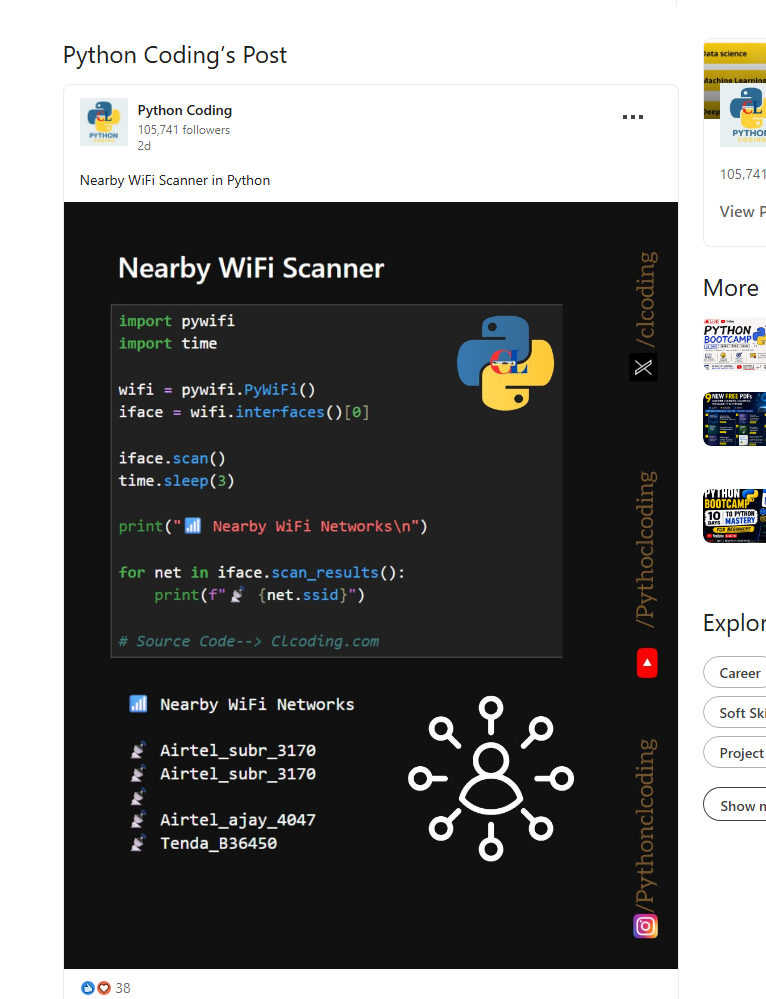

In [1]:
!pip install pywifi

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pywifi
import time

wifi = pywifi.PyWiFi()
iface = wifi.interfaces()[0]

iface.scan()
time.sleep(3)

print("📶 Nearby WiFi Networks\n")

for net in iface.scan_results():
    print(f"🕴 {net.ssid}")

ModuleNotFoundError: No module named 'comtypes'

In [3]:
import subprocess

result = subprocess.run(
    ["netsh", "wlan", "show", "networks"],
    capture_output=True,
    text=True
)

print(result.stdout)

The Wireless AutoConfig Service (wlansvc) is not running.

